# 2D Transient Heat Equation — Rectangular Domain

**PDE:**
$$\frac{\partial u}{\partial t} = \alpha\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right), \quad (x,y) \in [0,L_x]\times[0,L_y],\; t > 0$$

**Boundary conditions** (constant Dirichlet on all four sides):
$$u(0,y,t)=T_L,\quad u(L_x,y,t)=T_R,\quad u(x,0,t)=T_B,\quad u(x,L_y,t)=T_T$$

**Initial condition:** $u(x,y,0) = T_{\text{init}}$ (uniform)

## Analytical Solution

Decompose: $u = T_{\text{init}} + u_s + v$, where the shifted BCs are $T_i' = T_i - T_{\text{init}}$.

**Steady state $u_s$** — satisfies $\nabla^2 u_s = 0$ with shifted BCs via four-way superposition:
$$u_s = u_B + u_T + u_L + u_R$$
$$u_B(x,y) = \sum_{k=1,3,5,\ldots} \frac{4T_B'}{k\pi}\sin\!\left(\frac{k\pi x}{L_x}\right)\frac{\sinh\!\left(\frac{k\pi(L_y-y)}{L_x}\right)}{\sinh\!\left(\frac{k\pi L_y}{L_x}\right)}, \quad \text{(similarly for } u_T, u_L, u_R\text{)}$$

**Transient $v$** — satisfies heat eq. with zero BCs, $v(x,y,0) = -u_s(x,y)$:
$$v(x,y,t) = \sum_{m=1}^{M}\sum_{n=1}^{N} C_{mn}\,\sin\!\left(\frac{m\pi x}{L_x}\right)\sin\!\left(\frac{n\pi y}{L_y}\right)e^{-\alpha\lambda_{mn}^2 t}$$
$$\lambda_{mn}^2 = \left(\frac{m\pi}{L_x}\right)^2+\left(\frac{n\pi}{L_y}\right)^2, \qquad C_{mn} = \frac{4}{L_xL_y}\iint (-u_s)\,\sin\!\left(\frac{m\pi x}{L_x}\right)\sin\!\left(\frac{n\pi y}{L_y}\right)\,dx\,dy$$

## 1. Imports & domain constants

In [8]:
from pathlib import Path
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import time

# --- Domain ---
Lx, Ly = 1.0, 1.0       # metres

# --- Output grid (used in saved dataset) ---
NX = NY = 32
x_out = np.linspace(0, Lx, NX, dtype=np.float64)
y_out = np.linspace(0, Ly, NY, dtype=np.float64)
X_OUT, Y_OUT = np.meshgrid(x_out, y_out, indexing='ij')  # (NX, NY)

# --- Fine grid for C_mn quadrature (interior points only) ---
FINE = 256
x_f = np.linspace(0, Lx, FINE, dtype=np.float64)
y_f = np.linspace(0, Ly, FINE, dtype=np.float64)
X_F, Y_F = np.meshgrid(x_f, y_f, indexing='ij')  # (FINE, FINE)

# --- Truncation orders ---
N_STEADY    = 40   # terms per side in u_s (odd indices 1,3,...,2*N_STEADY-1)
M_TRANS = N_TRANS = 20   # modes per dimension in transient v

# Precompute spatial bases on output grid (shared across all cases)
m_arr = np.arange(1, M_TRANS + 1)
n_arr = np.arange(1, N_TRANS + 1)
SIN_MX_OUT = np.sin(np.outer(m_arr * np.pi / Lx, x_out))  # (M, NX)
SIN_NY_OUT = np.sin(np.outer(n_arr * np.pi / Ly, y_out))  # (N, NY)
LAMBDA_SQ  = (m_arr[:, None] * np.pi / Lx)**2 + (n_arr[None, :] * np.pi / Ly)**2  # (M, N)

# Precompute bases and quadrature weights on fine grid
SIN_MX_F = np.sin(np.outer(m_arr * np.pi / Lx, x_f))  # (M, FINE)
SIN_NY_F = np.sin(np.outer(n_arr * np.pi / Ly, y_f))  # (N, FINE)
wx = np.ones(FINE); wx[0] = wx[-1] = 0.5; wx *= Lx / (FINE - 1)
wy = np.ones(FINE); wy[0] = wy[-1] = 0.5; wy *= Ly / (FINE - 1)

OUTPUT_DIR = Path("dataset")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Output grid : {NX}×{NY}")
print(f"Fine grid   : {FINE}×{FINE}")
print(f"Modes       : {M_TRANS}×{N_TRANS} transient,  {N_STEADY} steady-state terms")

Output grid : 32×32
Fine grid   : 256×256
Modes       : 20×20 transient,  40 steady-state terms


## 2. Analytical solution

In [9]:
def _sinh_ratio(a_num: np.ndarray, a_den: np.ndarray) -> np.ndarray:
    """sinh(a_num)/sinh(a_den) without overflow. Assumes 0 <= a_num <= a_den."""
    large = a_den > 15.0
    with np.errstate(over='ignore', invalid='ignore'):
        direct = np.sinh(a_num) / np.where(large, 1.0, np.sinh(np.where(large, 1.0, a_den)))
    # For large arguments: sinh(a)/sinh(b) ≈ exp(a-b)
    return np.where(large, np.exp(a_num - a_den), direct)


def steady_state_2d(
    X: np.ndarray, Y: np.ndarray,
    T_L: float, T_R: float, T_B: float, T_T: float,
    N_terms: int = N_STEADY,
) -> np.ndarray:
    """
    Steady-state solution of Laplace's equation on [0,Lx]×[0,Ly]
    with constant Dirichlet BCs.  Uses 4-way superposition.
    Each sub-problem has one non-zero side and zeros on the other three.
    """
    u = np.zeros_like(X)
    for k in range(1, 2 * N_terms, 2):   # only odd k
        c = 4.0 / (k * np.pi)

        # Bottom (y=0, T_B) and Top (y=Ly, T_T)
        kx  = k * np.pi / Lx
        aLy = kx * Ly
        sx  = np.sin(kx * X)
        if T_B:
            u += c * T_B * sx * _sinh_ratio(kx * (Ly - Y), aLy * np.ones_like(Y))
        if T_T:
            u += c * T_T * sx * _sinh_ratio(kx * Y,        aLy * np.ones_like(Y))

        # Left (x=0, T_L) and Right (x=Lx, T_R)
        ky  = k * np.pi / Ly
        aLx = ky * Lx
        sy  = np.sin(ky * Y)
        if T_L:
            u += c * T_L * sy * _sinh_ratio(ky * (Lx - X), aLx * np.ones_like(X))
        if T_R:
            u += c * T_R * sy * _sinh_ratio(ky * X,        aLx * np.ones_like(X))
    return u


def solve_2d_heat(
    t_values,
    T_L: float, T_R: float, T_B: float, T_T: float,
    T_init: float, alpha: float,
) -> np.ndarray:
    """
    Full 2D transient solution on the OUTPUT grid for every t in t_values.

    Returns
    -------
    u : ndarray, shape (len(t_values), NX, NY)
    """
    # Shifted BCs so that IC = 0
    tL, tR, tB, tT = T_L - T_init, T_R - T_init, T_B - T_init, T_T - T_init

    # Steady state on fine grid → compute Fourier coefficients C_mn
    us_f = steady_state_2d(X_F, Y_F, tL, tR, tB, tT)

    # Vectorised trapezoid projection: C_mn = (4/LxLy) ∫∫ (-us) φ_m(x) φ_n(y) dx dy
    f_n = (-us_f) @ (SIN_NY_F * wy).T   # (FINE, N)
    C   = SIN_MX_F @ (f_n * wx[:, None]) # (M, N)
    C  *= 4.0 / (Lx * Ly)

    # Steady state on output grid
    us_out = steady_state_2d(X_OUT, Y_OUT, tL, tR, tB, tT)

    results = []
    for t in t_values:
        decay = np.exp(-alpha * LAMBDA_SQ * t)          # (M, N)
        v = SIN_MX_OUT.T @ (C * decay) @ SIN_NY_OUT    # (NX, NY)
        results.append(T_init + us_out + v)

    return np.stack(results, axis=0)  # (T, NX, NY)


print("Solver defined.")

Solver defined.


## 3. Verification

Check that:
1. BCs are satisfied at steady state (t → ∞)
2. IC is satisfied at t → 0⁺ (field is near T_init everywhere in the interior)
3. Symmetry case: T_L = T_R, T_B = T_T → field symmetric about both centre lines

=== Boundary check at t=50 (≈ steady state) ===
  Bottom  (y=0):   mean=140.89  (expect 150.0)
  Top     (y=Ly):  mean=46.96  (expect 50.0)
  Left    (x=0):   mean=75.14  (expect 80.0)
  Right   (x=Lx):  mean=18.79  (expect 20.0)
  (Boundary means are averaged over the full edge including corners,
   where adjacent BCs conflict; interior boundary points are more accurate.)

IC check: interior mean at t=0.05 = -0.0465 (expect ≈ 0.0)

Symmetry test (all BCs=100, T_init=0, t=5 s):
  Interior range : [40.5000, 99.3561]
  Full-grid max  : 103.5456  (Gibbs overshoot ≈ 3.55°C — expected for 40-term series)
  Left-right sym : max|u(x,y) - u(Lx-x,y)| = 6.66e-13
  Top-bot sym    : max|u(x,y) - u(x,Ly-y)| = 6.66e-13


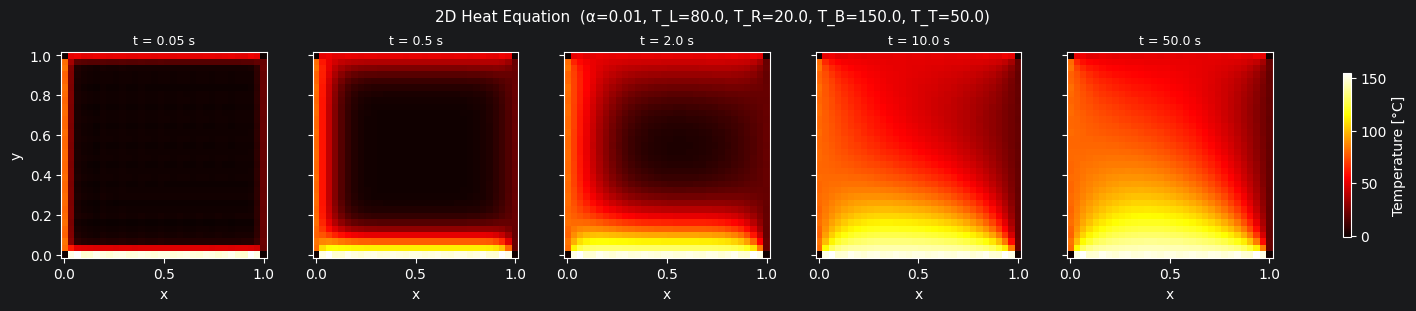

In [10]:
T_L, T_R, T_B, T_T, T_init, alpha = 80.0, 20.0, 150.0, 50.0, 0.0, 0.01
t_verify = np.array([0.05, 0.5, 2.0, 10.0, 50.0])

U = solve_2d_heat(t_verify, T_L, T_R, T_B, T_T, T_init, alpha)

# --- BCs at steady state (last time, t=50) ---
u_ss = U[-1]
print("=== Boundary check at t=50 (≈ steady state) ===")
print(f"  Bottom  (y=0):   mean={u_ss[:, 0].mean():.2f}  (expect {T_B})")
print(f"  Top     (y=Ly):  mean={u_ss[:, -1].mean():.2f}  (expect {T_T})")
print(f"  Left    (x=0):   mean={u_ss[0, :].mean():.2f}  (expect {T_L})")
print(f"  Right   (x=Lx):  mean={u_ss[-1, :].mean():.2f}  (expect {T_R})")
print("  (Boundary means are averaged over the full edge including corners,")
print("   where adjacent BCs conflict; interior boundary points are more accurate.)")

# --- IC check ---
u_early = U[0]   # t=0.05
interior = u_early[NX//4 : 3*NX//4, NY//4 : 3*NY//4]
print(f"\nIC check: interior mean at t=0.05 = {interior.mean():.4f} (expect ≈ {T_init})")

# --- Symmetry test ---
# All BCs = 100, T_init = 0: the unique harmonic solution is u_s = 100 (constant).
# The truncated Fourier-sinh series (N_STEADY odd terms) has small Gibbs oscillations
# near corners where adjacent sides would create a discontinuity in a finite sum.
# A few-percent overshoot just inside the boundary is expected and shrinks with more terms.
U_sym = solve_2d_heat([5.0], 100.0, 100.0, 100.0, 100.0, 0.0, 0.01)[0]
interior_sym = U_sym[1:-1, 1:-1]
gibbs_overshoot = max(0.0, U_sym.max() - 100.0)
print(f"\nSymmetry test (all BCs=100, T_init=0, t=5 s):")
print(f"  Interior range : [{interior_sym.min():.4f}, {interior_sym.max():.4f}]")
print(f"  Full-grid max  : {U_sym.max():.4f}  (Gibbs overshoot ≈ {gibbs_overshoot:.2f}°C — expected for {N_STEADY}-term series)")
print(f"  Left-right sym : max|u(x,y) - u(Lx-x,y)| = {np.abs(U_sym - U_sym[::-1, :]).max():.2e}")
print(f"  Top-bot sym    : max|u(x,y) - u(x,Ly-y)| = {np.abs(U_sym - U_sym[:, ::-1]).max():.2e}")

# --- Plot temporal evolution ---
# layout='constrained' avoids tight_layout conflict with multi-axes colorbars
fig, axes = plt.subplots(1, len(t_verify), figsize=(14, 3), sharey=True, layout='constrained')
vmin, vmax = U.min(), U.max()
for ax, u, t in zip(axes, U, t_verify):
    im = ax.pcolormesh(x_out, y_out, u.T, cmap='hot', vmin=vmin, vmax=vmax, shading='auto')
    ax.set_title(f't = {t} s', fontsize=9)
    ax.set_aspect('equal')
    ax.set_xlabel('x')
axes[0].set_ylabel('y')
fig.colorbar(im, ax=axes, label='Temperature [°C]', shrink=0.8)
fig.suptitle(f'2D Heat Equation  (α={alpha}, T_L={T_L}, T_R={T_R}, T_B={T_B}, T_T={T_T})', fontsize=11)
plt.savefig(OUTPUT_DIR / 'heat2d_evolution.png', dpi=120)
plt.show()

## 4. Dataset generation

Randomly sample `N_CASES` parameter combinations:

| Parameter | Range | Distribution |
|---|---|---|
| $T_L, T_R, T_B, T_T$ | [0, 200] °C | Uniform |
| $T_{\text{init}}$ | [0, 100] °C | Uniform |
| $\alpha$ | [0.005, 0.05] m²/s | Log-uniform |

Each case is solved at `N_TIMES` logarithmically-spaced time points covering ~0.01 – 3 diffusion time constants of the fastest case (α = 0.05).

In [11]:
RNG      = np.random.default_rng(42)
N_CASES  = 200
N_TIMES  = 10

# Time grid: log-spaced so we capture early transient AND near-steady
# Diffusion time for fastest case: τ = 1/(α*2π²) ≈ 1.01 s  (α=0.05)
# Diffusion time for slowest case: τ ≈ 10.1 s              (α=0.005)
t_values = np.logspace(np.log10(0.05), np.log10(30.0), N_TIMES)
print(f"t_values: {np.round(t_values, 3)}")

# --- Parameter sampling ---
BC_temps = RNG.uniform(0, 200, size=(N_CASES, 4))        # T_L, T_R, T_B, T_T
T_inits  = RNG.uniform(0, 100, size=N_CASES)
alphas   = np.exp(RNG.uniform(np.log(0.005), np.log(0.05), size=N_CASES))  # log-uniform

print(f"\n{N_CASES} cases × {N_TIMES} time steps = {N_CASES * N_TIMES} records")
print(f"Grid per record: {NX}×{NY} = {NX*NY} values")
print(f"Estimated storage: ~{N_CASES * N_TIMES * NX * NY * 4 / 1e6:.1f} MB (float32)")

t_values: [ 0.05   0.102  0.207  0.422  0.858  1.747  3.557  7.24  14.738 30.   ]

200 cases × 10 time steps = 2000 records
Grid per record: 32×32 = 1024 values
Estimated storage: ~8.2 MB (float32)


In [12]:
records = []
t_start = time.time()

for case_id in range(N_CASES):
    T_L, T_R, T_B, T_T = BC_temps[case_id]
    T_init = float(T_inits[case_id])
    alpha  = float(alphas[case_id])

    U = solve_2d_heat(t_values, T_L, T_R, T_B, T_T, T_init, alpha)  # (T, NX, NY)

    for ti, t in enumerate(t_values):
        records.append(
            dict(
                case_id = case_id,
                t       = float(t),
                alpha   = alpha,
                T_L     = float(T_L),
                T_R     = float(T_R),
                T_B     = float(T_B),
                T_T     = float(T_T),
                T_init  = T_init,
                T_field = U[ti].astype(np.float32).ravel().tolist(),   # length NX*NY
            )
        )

    if (case_id + 1) % 25 == 0:
        elapsed = time.time() - t_start
        eta = elapsed / (case_id + 1) * (N_CASES - case_id - 1)
        print(f"  case {case_id+1:>3}/{N_CASES}  elapsed={elapsed:.1f}s  ETA={eta:.0f}s")

print(f"\nDone — {len(records)} records in {time.time()-t_start:.1f}s")

  case  25/200  elapsed=12.7s  ETA=89s
  case  50/200  elapsed=25.8s  ETA=77s
  case  75/200  elapsed=38.8s  ETA=65s
  case 100/200  elapsed=51.9s  ETA=52s
  case 125/200  elapsed=65.0s  ETA=39s
  case 150/200  elapsed=78.2s  ETA=26s
  case 175/200  elapsed=91.4s  ETA=13s
  case 200/200  elapsed=104.5s  ETA=0s

Done — 2000 records in 104.5s


## 5. Save to Parquet

Schema:
- Scalar columns: `case_id`, `t`, `alpha`, `T_L`, `T_R`, `T_B`, `T_T`, `T_init`
- List column `T_field`: 1024 float32 values (row-major 32×32 grid)

In [13]:
schema = pa.schema([
    pa.field("case_id",  pa.int32()),
    pa.field("t",        pa.float32()),
    pa.field("alpha",    pa.float32()),
    pa.field("T_L",      pa.float32()),
    pa.field("T_R",      pa.float32()),
    pa.field("T_B",      pa.float32()),
    pa.field("T_T",      pa.float32()),
    pa.field("T_init",   pa.float32()),
    pa.field("T_field",  pa.list_(pa.float32())),
])

arrays = {
    "case_id" : pa.array([r["case_id"] for r in records], type=pa.int32()),
    "t"       : pa.array([r["t"]       for r in records], type=pa.float32()),
    "alpha"   : pa.array([r["alpha"]   for r in records], type=pa.float32()),
    "T_L"     : pa.array([r["T_L"]     for r in records], type=pa.float32()),
    "T_R"     : pa.array([r["T_R"]     for r in records], type=pa.float32()),
    "T_B"     : pa.array([r["T_B"]     for r in records], type=pa.float32()),
    "T_T"     : pa.array([r["T_T"]     for r in records], type=pa.float32()),
    "T_init"  : pa.array([r["T_init"]  for r in records], type=pa.float32()),
    "T_field" : pa.array([r["T_field"] for r in records], type=pa.list_(pa.float32())),
}

table = pa.table(arrays, schema=schema)

# Attach grid metadata (schema.metadata is None when no prior metadata exists)
meta = {
    b"grid_NX" : str(NX).encode(),
    b"grid_NY" : str(NY).encode(),
    b"Lx"      : str(Lx).encode(),
    b"Ly"      : str(Ly).encode(),
    b"x_grid"  : str(x_out.tolist()).encode(),
    b"y_grid"  : str(y_out.tolist()).encode(),
    b"N_cases" : str(N_CASES).encode(),
    b"N_times" : str(N_TIMES).encode(),
}
table = table.replace_schema_metadata({**(table.schema.metadata or {}), **meta})

out_path = OUTPUT_DIR / "heat2d_dataset.parquet"
pq.write_table(table, out_path, compression="snappy")

size_mb = out_path.stat().st_size / 1e6
print(f"Saved {len(records)} rows → {out_path}  ({size_mb:.2f} MB)")
print(f"Schema:\n{table.schema}")

Saved 2000 rows → dataset/heat2d_dataset.parquet  (8.71 MB)
Schema:
case_id: int32
t: float
alpha: float
T_L: float
T_R: float
T_B: float
T_T: float
T_init: float
T_field: list<item: float>
  child 0, item: float
-- schema metadata --
grid_NX: '32'
grid_NY: '32'
Lx: '1.0'
Ly: '1.0'
x_grid: '[0.0, 0.03225806451612903, 0.06451612903225806, 0.09677419354838' + 553
y_grid: '[0.0, 0.03225806451612903, 0.06451612903225806, 0.09677419354838' + 553
N_cases: '200'
N_times: '10'


## 6. Reload & quick sanity check

In [15]:
df = pq.read_table(out_path).to_pandas()
print(df.drop(columns="T_field").describe().round(2))
print(f"\nT_field dtype: {type(df['T_field'][0])}  length: {len(df['T_field'][0])}")

       case_id        t    alpha      T_L      T_R      T_B      T_T   T_init
count  2000.00  2000.00  2000.00  2000.00  2000.00  2000.00  2000.00  2000.00
mean     99.50     5.89     0.02    98.72   104.08    93.95    98.77    50.83
std      57.75     9.16     0.01    58.26    54.74    61.37    57.30    29.57
min       0.00     0.05     0.01     0.33     1.85     0.90     0.25     0.23
25%      49.75     0.21     0.01    48.44    62.71    37.01    47.85    24.51
50%      99.50     1.30     0.02   102.09   101.09    91.02    99.69    51.58
75%     149.25     7.24     0.03   150.10   154.13   153.08   147.01    76.67
max     199.00    30.00     0.05   199.52   199.82   198.94   199.75    99.34

T_field dtype: <class 'numpy.ndarray'>  length: 1024


## 7. Visualisation

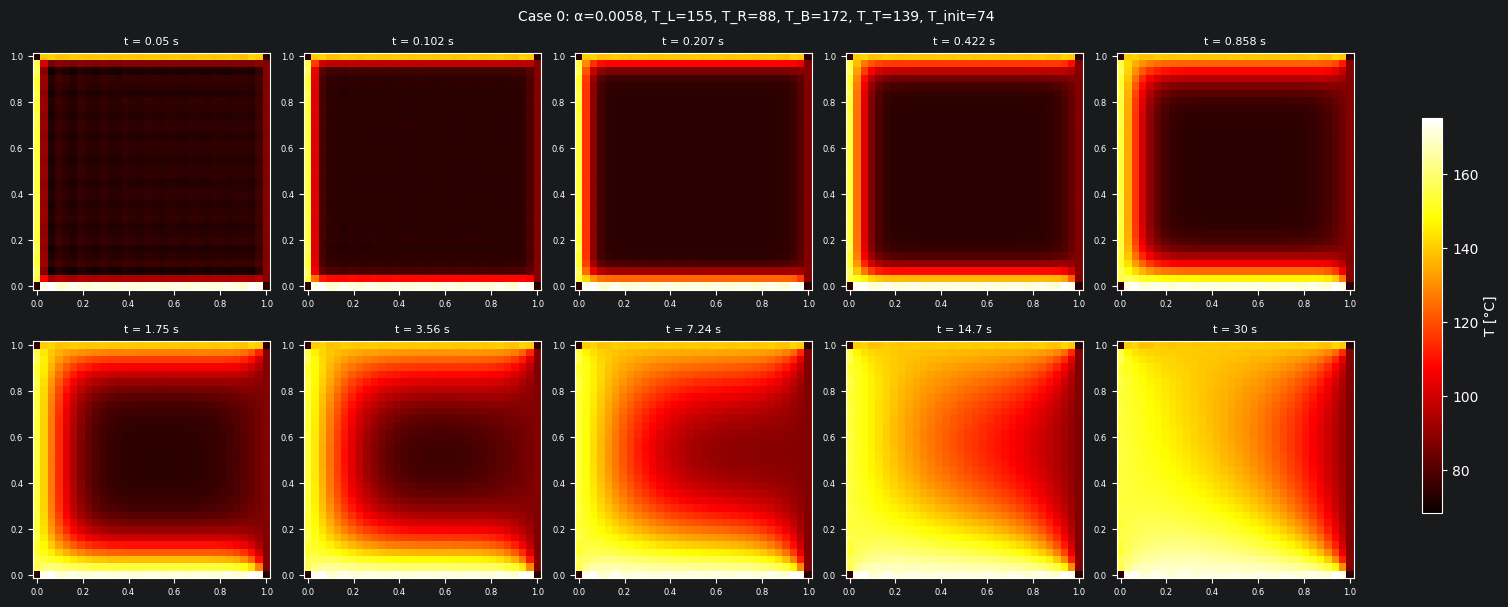

In [16]:
# --- One case: temporal snapshots ---
case_df = df[df["case_id"] == 0].sort_values("t").reset_index(drop=True)
meta_row = case_df.iloc[0]

fig, axes = plt.subplots(2, 5, figsize=(15, 6), layout='constrained')
vmin = min(np.array(row).min() for row in case_df["T_field"])
vmax = max(np.array(row).max() for row in case_df["T_field"])

for ax, (_, row) in zip(axes.ravel(), case_df.iterrows()):
    field = np.array(row["T_field"]).reshape(NX, NY)
    im = ax.pcolormesh(x_out, y_out, field.T, cmap="hot", vmin=vmin, vmax=vmax, shading="auto")
    ax.set_title(f"t = {row['t']:.3g} s", fontsize=8)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=6)

fig.colorbar(im, ax=axes, label="T [°C]", shrink=0.7)
fig.suptitle(
    f"Case 0: α={meta_row['alpha']:.4f}, "
    f"T_L={meta_row['T_L']:.0f}, T_R={meta_row['T_R']:.0f}, "
    f"T_B={meta_row['T_B']:.0f}, T_T={meta_row['T_T']:.0f}, "
    f"T_init={meta_row['T_init']:.0f}",
    fontsize=10,
)
plt.savefig(OUTPUT_DIR / "heat2d_case0_snapshots.png", dpi=120)
plt.show()

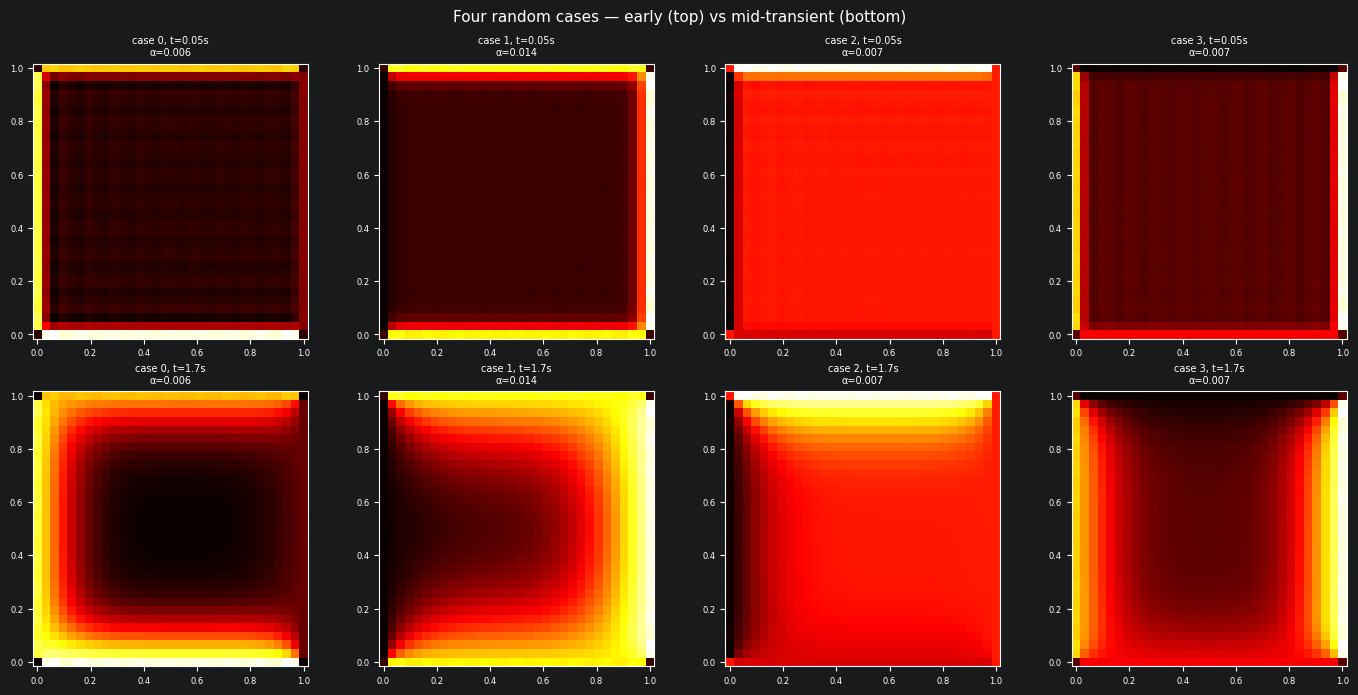

In [17]:
# --- Four different cases at the same mid-time index ---
mid_t_idx = N_TIMES // 2
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for col, cid in enumerate([0, 1, 2, 3]):
    cdf = df[(df["case_id"] == cid)].sort_values("t").reset_index(drop=True)
    for row_idx, t_idx in enumerate([0, mid_t_idx]):
        row_data = cdf.iloc[t_idx]
        field = np.array(row_data["T_field"]).reshape(NX, NY)
        ax = axes[row_idx, col]
        ax.pcolormesh(x_out, y_out, field.T, cmap="hot", shading="auto")
        ax.set_aspect("equal")
        ax.set_title(
            f"case {cid}, t={row_data['t']:.2g}s\n"
            f"α={row_data['alpha']:.3f}",
            fontsize=7,
        )
        ax.tick_params(labelsize=6)

fig.suptitle("Four random cases — early (top) vs mid-transient (bottom)", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "heat2d_cases_comparison.png", dpi=120)
plt.show()

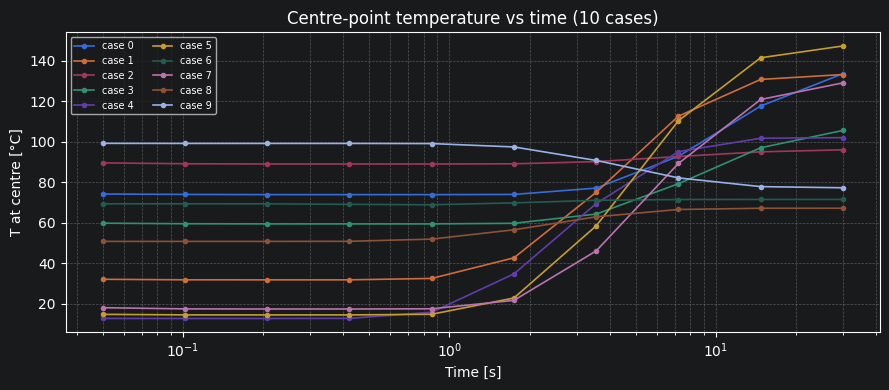

In [18]:
# --- Centre-point temperature vs time for 10 random cases ---
cx, cy = NX // 2, NY // 2

fig, ax = plt.subplots(figsize=(9, 4))
for cid in range(10):
    cdf = df[df["case_id"] == cid].sort_values("t")
    t_arr  = cdf["t"].values
    T_centre = np.array([np.array(r).reshape(NX, NY)[cx, cy] for r in cdf["T_field"]])
    ax.plot(t_arr, T_centre, marker="o", ms=3, lw=1.2, label=f"case {cid}")

ax.set_xlabel("Time [s]")
ax.set_ylabel("T at centre [°C]")
ax.set_xscale("log")
ax.set_title("Centre-point temperature vs time (10 cases)")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "heat2d_centre_vs_time.png", dpi=120)
plt.show()